In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_sample = pd.read_csv('data/train.csv')

df_sample.head()

C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_18552\463323951.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sample = pd.read_csv('data/train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
df_sample.info()
df_sample.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [4]:
df_sample.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [5]:
df_sample['Date'] = pd.to_datetime(df_sample['Date'])

df_sample['Day'] = df_sample['Date'].dt.day
df_sample['Month'] = df_sample['Date'].dt.month
df_sample['Year'] = df_sample['Date'].dt.year

df_sample.drop('Date', axis=1, inplace=True)

In [6]:
for col in df_sample.select_dtypes(include=['object']).columns:
    df_sample[col] = df_sample[col].astype(str)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_sample.select_dtypes(include=['object']).columns:
    df_sample[col] = le.fit_transform(df_sample[col])

C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_18552\212786746.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_sample.select_dtypes(include=['object']).columns:


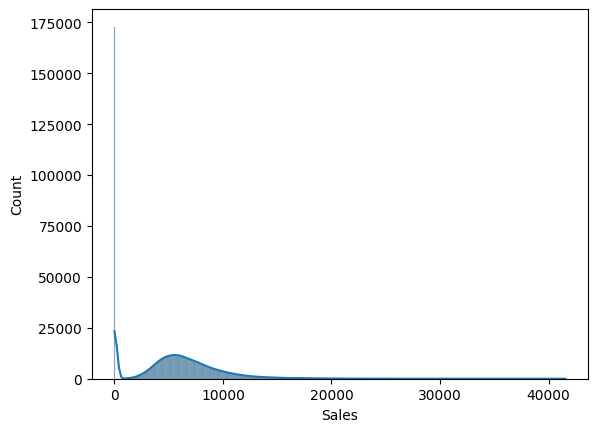

In [ ]:
sns.histplot(df['Sales'], kde=True)
plt.show()

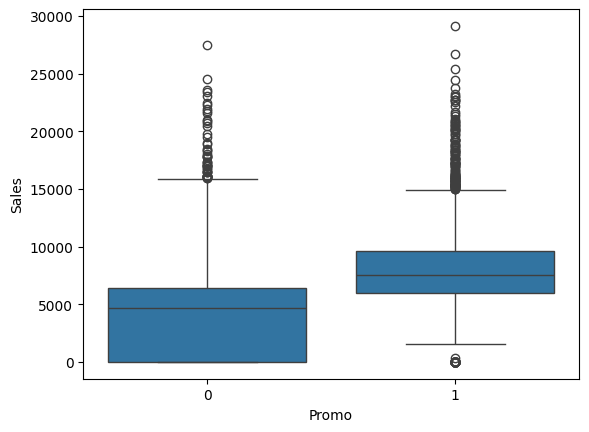

In [ ]:
sns.boxplot(x='Promo', y='Sales', data=df_sample)
plt.show()

In [ ]:
df_sample = df.sample(n=10000, random_state=42)

In [9]:
X = df_sample.drop('Sales', axis=1)
y = df_sample['Sales']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [24]:
def evaluate(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return mae, mse, rmse, r2

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

param_lr = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid_lr = GridSearchCV(LinearRegression(), param_lr, cv=3)
grid_lr.fit(X_train, y_train)

lr_best = grid_lr.best_estimator_

y_pred_lr = lr_best.predict(X_test)

eval_lr = evaluate(y_test, y_pred_lr)

print("Linear Regression")
print("Best Params:", grid_lr.best_params_)
print("MAE, MSE, RMSE, R2:", eval_lr)

Linear Regression
Best Params: {'fit_intercept': False, 'positive': False}
MAE, MSE, RMSE, R2: (946.5123515514078, 1911769.0667716768, np.float64(1382.6673738725726), 0.8630733342212581)


In [26]:
from sklearn.tree import DecisionTreeRegressor

param_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(DecisionTreeRegressor(), param_dt, cv=3, n_jobs=-1)
grid_dt.fit(X_train, y_train)

dt_best = grid_dt.best_estimator_

y_pred_dt = dt_best.predict(X_test)

eval_dt = evaluate(y_test, y_pred_dt)

print("\nDecision Tree")
print("Best Params:", grid_dt.best_params_)
print("MAE, MSE, RMSE, R2:", eval_dt)


Decision Tree
Best Params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
MAE, MSE, RMSE, R2: (522.0881807466517, 830647.9850766907, np.float64(911.3989165435137), 0.9405064863694831)


In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor()

random_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_rf,
    n_iter=10,      # hanya 10 percobaan (CEPAT)
    cv=2,           # lebih ringan
    n_jobs=-1,
    random_state=42
)

random_rf.fit(X_train, y_train)

rf_best = random_rf.best_estimator_

y_pred_rf = rf_best.predict(X_test)

eval_rf = evaluate(y_test, y_pred_rf)

print("Random Forest")
print("Best Params:", random_rf.best_params_)
print("MAE, MSE, RMSE, R2:", eval_rf)

Random Forest
Best Params: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
MAE, MSE, RMSE, R2: (451.9404495112114, 551239.0893686411, np.float64(742.4547726081644), 0.9605185940780929)


In [29]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [eval_lr[0], eval_dt[0], eval_rf[0]],
    'MSE': [eval_lr[1], eval_dt[1], eval_rf[1]],
    'RMSE': [eval_lr[2], eval_dt[2], eval_rf[2]],
    'R2 Score': [eval_lr[3], eval_dt[3], eval_rf[3]]
})

print(results)

               Model         MAE           MSE         RMSE  R2 Score
0  Linear Regression  946.512352  1.911769e+06  1382.667374  0.863073
1      Decision Tree  522.088181  8.306480e+05   911.398917  0.940506
2      Random Forest  451.940450  5.512391e+05   742.454773  0.960519
